In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_linear = pd.read_csv('linear_coef_sign.csv')
df_linear['Estimator'] = 'Linear'
df_linear.head()

,Stimulus,TargetScore,features,params,p_values,params_significant,Cluster,Time Period,Frequency,Estimator
0,Haiku,Aesthetic_Appeal,"CL1_(-4, 0)_alpha",-0.101039,0.370444,0.0,CL1,"(-4, 0)",alpha,Linear
1,Haiku,Vivid_Imagery,"CL1_(-4, 0)_alpha",0.023550,0.717638,0.0,CL1,"(-4, 0)",alpha,Linear
2,Haiku,Moved,"CL1_(-4, 0)_alpha",0.204878,0.065852,0.0,CL1,"(-4, 0)",alpha,Linear
3,Haiku,Originality,"CL1_(-4, 0)_alpha",0.119555,0.289611,0.0,CL1,"(-4, 0)",alpha,Linear
4,Haiku,Creativity,"CL1_(-4, 0)_alpha",0.047008,0.672690,0.0,CL1,"(-4, 0)",alpha,Linear


In [3]:
df_linear.shape

(1350, 10)

In [4]:
df_lgb = pd.read_csv('shap_values_lightgbm.csv')
df_lgb['Estimator'] = 'LightGBM'
df_lgb.head()

,Stimulus,TargetScore,features,SHAP_value,Cluster,Time Period,Frequency,Estimator
0,Haiku,Aesthetic_Appeal,"CL1_(-4, 0)_alpha",-0.000816,CL1,"(-4, 0)",alpha,LightGBM
1,Haiku,Aesthetic_Appeal,"CL1_(-4, 0)_alpha",-0.000988,CL1,"(-4, 0)",alpha,LightGBM
2,Haiku,Aesthetic_Appeal,"CL1_(-4, 0)_alpha",-0.002266,CL1,"(-4, 0)",alpha,LightGBM
3,Haiku,Aesthetic_Appeal,"CL1_(-4, 0)_alpha",-0.002266,CL1,"(-4, 0)",alpha,LightGBM
4,Haiku,Aesthetic_Appeal,"CL1_(-4, 0)_alpha",-0.000816,CL1,"(-4, 0)",alpha,LightGBM


In [5]:
df_lgb.shape

(4441500, 8)

In [6]:
df_lgb.columns

Index(['Stimulus', 'TargetScore', 'features', 'SHAP_value', 'Cluster',
       'Time Period', 'Frequency', 'Estimator'],
      dtype='object')

In [7]:
cols_group = ['Stimulus', 'TargetScore', 'features', 'Cluster', 'Time Period', 'Frequency', 'Estimator']
cols_merge = ['Stimulus', 'TargetScore', 'features', 'Cluster', 'Time Period', 'Frequency']

In [8]:
df_lgb_grouped_sum = df_lgb.groupby(by=cols_group)['SHAP_value'].sum().reset_index()

df_lgb_grouped_sum.head()

,Stimulus,TargetScore,features,Cluster,Time Period,Frequency,Estimator,SHAP_value
0,Control,Aesthetic_Appeal,"CL1_(-4, 0)_alpha",CL1,"(-4, 0)",alpha,LightGBM,18.557620
1,Control,Aesthetic_Appeal,"CL1_(-4, 0)_beta",CL1,"(-4, 0)",beta,LightGBM,89.823032
2,Control,Aesthetic_Appeal,"CL1_(-4, 0)_delta",CL1,"(-4, 0)",delta,LightGBM,151.607017
3,Control,Aesthetic_Appeal,"CL1_(-4, 0)_lower gamma",CL1,"(-4, 0)",lower gamma,LightGBM,26.114915
4,Control,Aesthetic_Appeal,"CL1_(-4, 0)_theta",CL1,"(-4, 0)",theta,LightGBM,1.870046


In [9]:
df_lgb_grouped_sum.shape

(1350, 8)

In [10]:
df_lgb_grouped_mean = df_lgb.groupby(by=cols_group)['SHAP_value'].mean().reset_index()

df_lgb_grouped_mean.head()

,Stimulus,TargetScore,features,Cluster,Time Period,Frequency,Estimator,SHAP_value
0,Control,Aesthetic_Appeal,"CL1_(-4, 0)_alpha",CL1,"(-4, 0)",alpha,LightGBM,0.005641
1,Control,Aesthetic_Appeal,"CL1_(-4, 0)_beta",CL1,"(-4, 0)",beta,LightGBM,0.027302
2,Control,Aesthetic_Appeal,"CL1_(-4, 0)_delta",CL1,"(-4, 0)",delta,LightGBM,0.046081
3,Control,Aesthetic_Appeal,"CL1_(-4, 0)_lower gamma",CL1,"(-4, 0)",lower gamma,LightGBM,0.007938
4,Control,Aesthetic_Appeal,"CL1_(-4, 0)_theta",CL1,"(-4, 0)",theta,LightGBM,0.000568


In [11]:
df_all = pd.merge(df_linear, df_lgb_grouped_sum, on=cols_merge)
df_all.head()

,Stimulus,TargetScore,features,params,p_values,params_significant,Cluster,Time Period,Frequency,Estimator_x,Estimator_y,SHAP_value
0,Haiku,Aesthetic_Appeal,"CL1_(-4, 0)_alpha",-0.101039,0.370444,0.0,CL1,"(-4, 0)",alpha,Linear,LightGBM,18.860912
1,Haiku,Vivid_Imagery,"CL1_(-4, 0)_alpha",0.023550,0.717638,0.0,CL1,"(-4, 0)",alpha,Linear,LightGBM,265.342729
2,Haiku,Moved,"CL1_(-4, 0)_alpha",0.204878,0.065852,0.0,CL1,"(-4, 0)",alpha,Linear,LightGBM,0.959311
3,Haiku,Originality,"CL1_(-4, 0)_alpha",0.119555,0.289611,0.0,CL1,"(-4, 0)",alpha,Linear,LightGBM,9.607085
4,Haiku,Creativity,"CL1_(-4, 0)_alpha",0.047008,0.672690,0.0,CL1,"(-4, 0)",alpha,Linear,LightGBM,0.889396


In [12]:
df_all_test = df_all[(df_all.Stimulus=='Haiku')&(df_all.TargetScore=='Aesthetic_Appeal')]

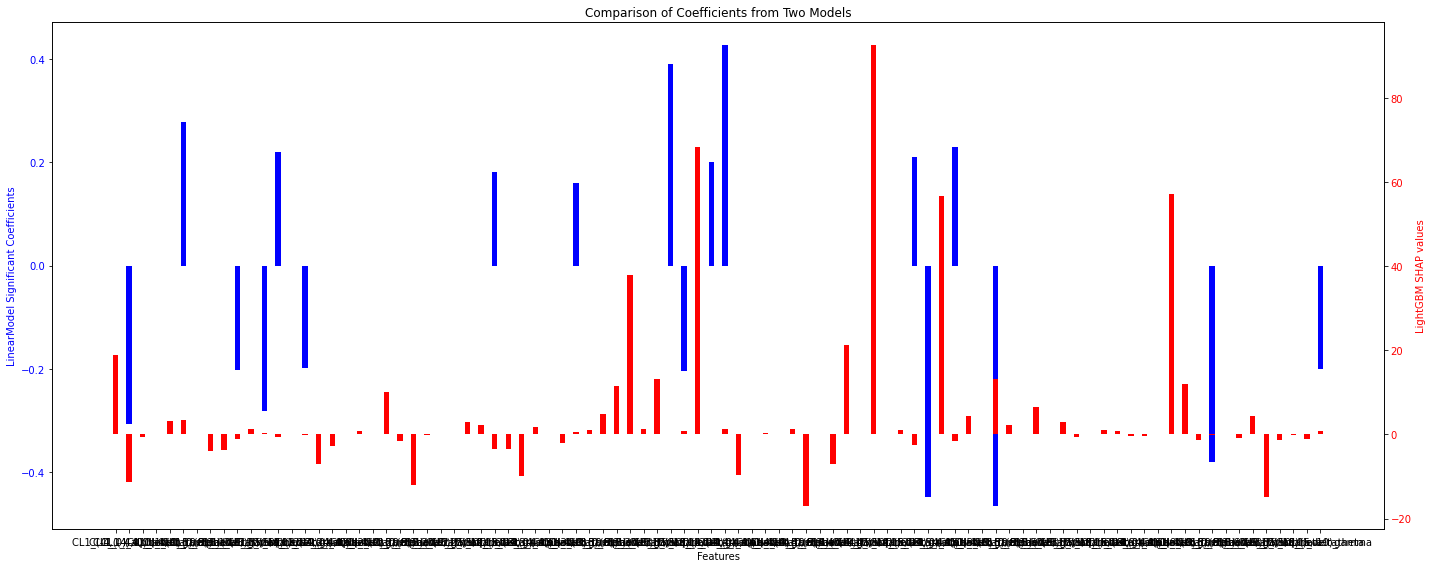

In [13]:
x = np.arange(df_all_test.shape[0])  # x locations for the bars

fig, ax1 = plt.subplots(figsize=(20, 8))

# First y-axis
ax1.bar(x, df_all_test['params_significant'], width=0.4, color='b', label='Linear Model')
ax1.set_ylabel('LinearModel Significant Coefficients', color='b')
ax1.tick_params(axis='y', labelcolor='b')

# Second y-axis
ax2 = ax1.twinx()
ax2.bar(x, df_all_test['SHAP_value'], width=0.4, color='r', label='LightGBM')
ax2.set_ylabel('LightGBM SHAP values', color='r')
ax2.tick_params(axis='y', labelcolor='r')

# X-axis settings
plt.xticks(x, df_all_test.features)
ax1.set_xlabel('Features')

# Title and layout
plt.title('Comparison of Coefficients from Two Models')
fig.tight_layout()

plt.show()

In [14]:
df_all_test.to_csv('../project_eeg/code/eeg_streamlit_dashboard/streamlit_app/data/df_all_test.csv', index=False)
df_all.to_csv('../project_eeg/code/eeg_streamlit_dashboard/streamlit_app/data/df_all.csv', index=False)

In [15]:
df_all_mean = pd.merge(df_linear, df_lgb_grouped_mean, on=cols_merge)
df_all_mean.head()

,Stimulus,TargetScore,features,params,p_values,params_significant,Cluster,Time Period,Frequency,Estimator_x,Estimator_y,SHAP_value
0,Haiku,Aesthetic_Appeal,"CL1_(-4, 0)_alpha",-0.101039,0.370444,0.0,CL1,"(-4, 0)",alpha,Linear,LightGBM,0.005733
1,Haiku,Vivid_Imagery,"CL1_(-4, 0)_alpha",0.023550,0.717638,0.0,CL1,"(-4, 0)",alpha,Linear,LightGBM,0.080651
2,Haiku,Moved,"CL1_(-4, 0)_alpha",0.204878,0.065852,0.0,CL1,"(-4, 0)",alpha,Linear,LightGBM,0.000292
3,Haiku,Originality,"CL1_(-4, 0)_alpha",0.119555,0.289611,0.0,CL1,"(-4, 0)",alpha,Linear,LightGBM,0.002920
4,Haiku,Creativity,"CL1_(-4, 0)_alpha",0.047008,0.672690,0.0,CL1,"(-4, 0)",alpha,Linear,LightGBM,0.000270


In [16]:
df_all_test_mean = df_all_mean[(df_all_mean.Stimulus=='Haiku')&(df_all_mean.TargetScore=='Aesthetic_Appeal')]

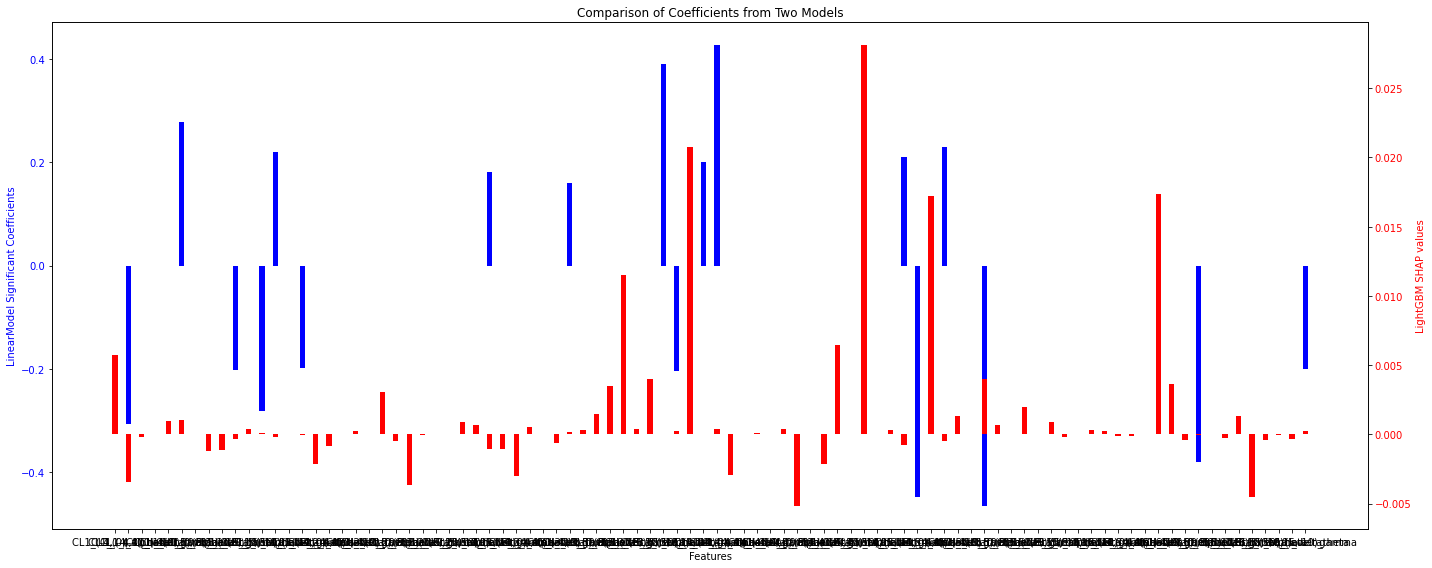

In [17]:
x = np.arange(df_all_test_mean.shape[0])  # x locations for the bars

fig, ax1 = plt.subplots(figsize=(20, 8))

# First y-axis
ax1.bar(x, df_all_test_mean['params_significant'], width=0.4, color='b', label='Linear Model')
ax1.set_ylabel('LinearModel Significant Coefficients', color='b')
ax1.tick_params(axis='y', labelcolor='b')

# Second y-axis
ax2 = ax1.twinx()
ax2.bar(x, df_all_test_mean['SHAP_value'], width=0.4, color='r', label='LightGBM')
ax2.set_ylabel('LightGBM SHAP values', color='r')
ax2.tick_params(axis='y', labelcolor='r')

# X-axis settings
plt.xticks(x, df_all_test_mean.features)
ax1.set_xlabel('Features')

# Title and layout
plt.title('Comparison of Coefficients from Two Models')
fig.tight_layout()

plt.show()

In [18]:
df_all_test_mean.to_csv('../project_eeg/code/eeg_streamlit_dashboard/streamlit_app/data/df_all_test_mean.csv', index=False)
df_all_mean.to_csv('../project_eeg/code/eeg_streamlit_dashboard/streamlit_app/data/df_all_mean.csv', index=False)

In [19]:
df_lgb_grouped_mean.to_csv('../project_eeg/code/eeg_streamlit_dashboard/streamlit_app/data/shap_lgb_mean.csv', index=False)
df_lgb_grouped_sum.to_csv('../project_eeg/code/eeg_streamlit_dashboard/streamlit_app/data/shap_lgb_sum.csv', index=False)